# <img src="https://i.imgur.com/1voq3gc.png" width=100 height=100, style="vertical-align:middle;margin:0px 12px"/> Assignment 4
---

<!-- Disclaim: Please note that the examples there are for demonstration purposes only to introduce basic tools and functions which might be helpful in future when one wish to start working with their own research project.  -->

## Environment Setup 
---

### Development Environment Setup
Make sure to read [Development Setup Guideline](https://moodle.oulu.fi/pluginfile.php/2761255/mod_resource/content/2/Development_setup_guideline.pdf) for development environment setup. 

This assignment consists of the following files:

- Main notebook: `Assignment_4.ipynb`
- Data: data_assignment4.csv (assignment 2 included OAI data access and tasks related to that data, so you can have a look on assignment 2)

For those who use Google Colab, upload those files to your `Colab Notebooks` folder on `Google Drive`.

### Submission

- Rename the notebook with solutions from `Assignment_4.ipynb` --> `<First name>.<Last name>.Assignment_4.ipynb`
- For more details, reference to the [FAQs page](https://moodle.oulu.fi/mod/page/view.php?id=1788245)
- Note: Only submit the notebook with solutions in .ipynb format. Do NOT compress it.


### Any questions
- Reference to [FAQs page](https://moodle.oulu.fi/mod/page/view.php?id=1788245).
- Or post your questions to [Q&A forum](https://moodle.oulu.fi/mod/forum/view.php?id=1755240).

---
# Prerequisite: OAI Data Access Permission
Before proceeding with this assignment, ensure that you have obtained access to the **OAI dataset**.

Follow the instruction in the [Guideline](https://moodle.oulu.fi/mod/assign/view.php?id=1794354) to obtain access permission to the OAI dataset. 

- If you have **not** previously submitted an access request, this step is **mandatory**.  
- If you **already have access**, you may **skip this step** and proceed with the assignment. 

---
---
# Variance analysis (15pts)

---

#### **Data Introduction**  

In this assignment, we provide a **preprocessed dataset**, `data_assignment4.csv`, containing data from 3,433 participants. For each participant, a random knee was selected at baseline.  

The dataset consists of 9 columns: **`ID`**, **`SIDE`**, **`Site`**, **`SEX`**, **`AGE`**, **`BMI`**, **`INJURY`**, **`KL`**, and **`JSW`**.  

While some variables (**`ID`**, **`Site`**, **`SEX`**, **`AGE`**, and **`BMI`**) have been introduced in previous assignments and lectures, we will focus on **three key variables** for this assignment:  

- **Kellgren and Lawrence (`KL`) grading system** is used to assess the severity of osteoarthritis (OA). It classifies OA into 5 levels (0–4) based on radiographic features.  

<div align="center">
<img src="https://www.researchgate.net/publication/359459364/figure/fig2/AS:11431281179347951@1691186606793/Examples-of-knee-osteoarthritis-images-and-the-corresponding-classification-criteria_W640.jpg" width="700"/>
</div>  
 
- **Joint Space Width (`JSW`)** is a common biomarker for tracking OA progression. It is measured from radiographs and divided into Medial JSW and Lateral JSW. In this assignment, we extracted medial JSW. For further details, please refer to the data description. 

<div align="center">
<img src="https://www.researchgate.net/publication/355019446/figure/fig1/AS:1075841551339520@1633512022164/Automatic-measurements-of-joint-space-width-JSW-medial-and-lateral-JSW-using.png" width="500"/>
</div>  


- **Injury History (`INJURY`)**: The **`INJURY`** variable indicates whether the selected knee has ever been badly injured. Please refer to the **data description** for more details.  

**Notes:** The variables **`KL`**, **`JSW`**, and **`INJURY`** were recorded during follow-up visits. Two knees of each participant was graded individually, thus there exists the **`SIDE`** column to differentiate them.  

---


In [6]:
# Install the dependencies
%pip install numpy scipy pandas
%pip install matplotlib seaborn
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [7]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy

# Load data (remember to save data_assignmnet4.csv to same location where Assignment_4.ibynb is located). 
csv_path = Path("C:/Users/Hi/OneDrive - University of Oulu and Oamk/Documents/EBDS/Python for data statistics/Assignment 4/data_assignment4.csv")
df_ori_OAI = pd.read_csv(csv_path)  


In [8]:
# Verify the data loaded correctly
print("DataFrame Shape:", df_ori_OAI.shape)  # Shows number of rows and columns
print("First few rows:\n", df_ori_OAI.head())  # Displays the first 5 rows

DataFrame Shape: (3433, 9)
First few rows:
         ID SIDE Site   AGE  SEX   BMI  INJURY   KL   JSW
0  9789712    R    E  48.0  0.0  30.3     1.0  2.0  5.90
1  9168534    L    C  72.0  0.0  32.4     1.0  1.0  5.56
2  9441861    L    A  58.0  0.0  26.7     0.0  3.0  3.65
3  9393208    L    A  66.0  1.0  23.8     0.0  1.0  6.82
4  9875231    L    D  53.0  0.0  32.0     1.0  2.0  5.33


In [9]:
print(df_ori_OAI["SEX"].dtype, df_ori_OAI["JSW"].dtype, df_ori_OAI["BMI"].dtype)

float64 float64 float64


In [10]:
print(df_ori_OAI["SIDE"].dtype, df_ori_OAI["KL"].dtype)

object float64


In [11]:
print(df_ori_OAI["AGE"].dtype, df_ori_OAI["Site"].dtype, df_ori_OAI["INJURY"].dtype)

float64 object float64


In [12]:
# function to visualie data

def plot_sample_groups(df, i, o):
    """Visualize factor distribution in the complete sample and individual groups."""
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 6))
    
    hue_order = sorted(df[i].unique())

    sns.boxplot(data=df, x=o, color="black", fill=False, ax=ax[0, 0])
    sns.boxplot(data=df, x=o, hue=i, hue_order=hue_order, fill=False, gap=.2, ax=ax[0, 1])

    sns.kdeplot(data=df, x=o, color="black", ax=ax[1, 0])
    sns.kdeplot(data=df, x=o, hue=i, ax=ax[1, 1], hue_order=hue_order, common_norm=False)
    plt.tight_layout()
    return fig, ax

---
## **Task 1: Data assumptions test (7 pts)**
Since ANOVA test based on 3 assumptions:
- **Normality** - observed data must follow normal distribution
- **Homogeneity** of variance a.k.a homoscedasticity - variance is the same across the groups
- **Independence** - This needs to be addressed at the study design level

The aim of this task is to practice normality and homoscedasticity, which are the reqiurements before ANOVA test. You will sample data to ensure pass these tests.

---
### **Task 1.1 : Categorize Data Before Sampling (1 pt)**

Before sampling, prepare the dataset by categorizing the OA status based on the Kellgren-Lawrence (KL) grading system.  

1. Create a new column, **`OA_status`**, using the following conditions:  
   - If **KL ≤ 1**, label as **0** (No or early OA).
   - If **KL = 2**, label as **1** (Mild OA).  
   - If **KL > 2**, label as **2** (Moderate to severe OA).  
2. Convert the `OA_status` column to **integer** type.  
3. **Remove Missing Values** in the dataset.  


In [15]:
# Change the data type to appropriate data types
# Convert data types
df_ori_OAI['ID'] = df_ori_OAI['ID'].astype(int)           # ID to integer
df_ori_OAI['SIDE'] = df_ori_OAI['SIDE'].astype('category') # SIDE to category
df_ori_OAI['Site'] = df_ori_OAI['Site'].astype('category') # Site to category
df_ori_OAI['SEX'] = df_ori_OAI['SEX'].astype(int)          # SEX to integer
df_ori_OAI['AGE'] = df_ori_OAI['AGE'].astype(int)          # AGE to integer
df_ori_OAI['BMI'] = df_ori_OAI['BMI'].astype(float)        # BMI stays float (redundant but explicit)
df_ori_OAI['INJURY'] = df_ori_OAI['INJURY'].astype(int)    # INJURY to integer
df_ori_OAI['KL'] = df_ori_OAI['KL'].astype(int)            # KL to integer
df_ori_OAI['JSW'] = df_ori_OAI['JSW'].astype(float)        # JSW stays float (redundant but explicit)



In [16]:
# Verify the new types
print(df_ori_OAI.dtypes)

ID           int32
SIDE      category
Site      category
AGE          int32
SEX          int32
BMI        float64
INJURY       int32
KL           int32
JSW        float64
dtype: object


In [17]:
df_ori_OAI.isna().sum()

ID         0
SIDE       0
Site       0
AGE        0
SEX        0
BMI        0
INJURY     0
KL         0
JSW       11
dtype: int64

In [18]:
df_ori_OAI.isnull().sum()

ID         0
SIDE       0
Site       0
AGE        0
SEX        0
BMI        0
INJURY     0
KL         0
JSW       11
dtype: int64

In [19]:
print(df_ori_OAI['INJURY'].unique())  # Check for non-integer floats or NaN


[1 0]


In [20]:
print(df_ori_OAI['SEX'].unique())     # Same for SEX


[0 1]


In [21]:
print(df_ori_OAI['KL'].unique())      # Same for KL

[2 1 3 4 0]


In [22]:
print(df_ori_OAI['SIDE'].unique())

['R', 'L']
Categories (2, object): ['L', 'R']


In [23]:
print(df_ori_OAI['Site'].unique())

['E', 'C', 'A', 'D', 'B']
Categories (5, object): ['A', 'B', 'C', 'D', 'E']


In [24]:
# # Define the categorization function
# def categorize_KL(df):
#     def classify_oa(kl):
#         if pd.isna(kl):  # Handle NaN
#             return None  # or np.nan
#         elif kl <= 1:
#             return 0  # No or early OA
#         elif kl == 2:
#             return 1  # Mild OA
#         elif kl > 2:
#             return 2  # Moderate to severe OA
    
#     df['OA_status'] = df['KL'].apply(classify_oa)
#     return df  # Return the modified DataFrame

# # Apply the function
# df_ori_OAI = categorize_KL(df_ori_OAI)

# # Verify
# print(df_ori_OAI[['KL', 'OA_status']].head(10))
# print(df_ori_OAI['OA_status'].value_counts())

In [25]:
print(f'Original data:\n{df_ori_OAI}')
def categorize_KL(df):
    # TODO: Write your code here
    return None
    
df_OAI = categorize_KL(df_ori_OAI) 
print(f'Preprocessed data:\n{df_OAI}')

Original data:
           ID SIDE Site  AGE  SEX   BMI  INJURY  KL   JSW
0     9789712    R    E   48    0  30.3       1   2  5.90
1     9168534    L    C   72    0  32.4       1   1  5.56
2     9441861    L    A   58    0  26.7       0   3  3.65
3     9393208    L    A   66    1  23.8       0   1  6.82
4     9875231    L    D   53    0  32.0       1   2  5.33
...       ...  ...  ...  ...  ...   ...     ...  ..   ...
3428  9739050    L    B   68    0  25.3       0   0  6.21
3429  9341449    R    C   62    0  23.5       0   0  6.81
3430  9803621    R    C   59    1  32.3       1   0  6.20
3431  9425183    R    A   66    1  37.4       0   3  5.05
3432  9511862    L    C   58    1  31.6       0   0  5.30

[3433 rows x 9 columns]
Preprocessed data:
None


In [26]:
# Define the categorization function
print(f'Original data:\n{df_ori_OAI}')
def categorize_KL(df):
    conditions = [
        (df['KL'] <= 1),  # KL ≤ 1
        (df['KL'] == 2),  # KL = 2
        (df['KL'] > 2)    # KL > 2
    ]
    choices = [0, 1, 2]
    df['OA_status'] = np.select(conditions, choices, default=np.nan)
    return df

# Apply the function
df_ori_OAI = categorize_KL(df_ori_OAI)

# Verify
print(df_ori_OAI[['KL', 'OA_status']].head(10))
print(df_ori_OAI['OA_status'].value_counts())

df_OAI = categorize_KL(df_ori_OAI) 
print(f'Preprocessed data:\n{df_OAI}')

Original data:
           ID SIDE Site  AGE  SEX   BMI  INJURY  KL   JSW
0     9789712    R    E   48    0  30.3       1   2  5.90
1     9168534    L    C   72    0  32.4       1   1  5.56
2     9441861    L    A   58    0  26.7       0   3  3.65
3     9393208    L    A   66    1  23.8       0   1  6.82
4     9875231    L    D   53    0  32.0       1   2  5.33
...       ...  ...  ...  ...  ...   ...     ...  ..   ...
3428  9739050    L    B   68    0  25.3       0   0  6.21
3429  9341449    R    C   62    0  23.5       0   0  6.81
3430  9803621    R    C   59    1  32.3       1   0  6.20
3431  9425183    R    A   66    1  37.4       0   3  5.05
3432  9511862    L    C   58    1  31.6       0   0  5.30

[3433 rows x 9 columns]
   KL  OA_status
0   2        1.0
1   1        0.0
2   3        2.0
3   1        0.0
4   2        1.0
5   2        1.0
6   4        2.0
7   3        2.0
8   2        1.0
9   0        0.0
OA_status
1.0    1354
0.0    1293
2.0     786
Name: count, dtype: int64
Prepr

In [27]:
print(df_ori_OAI.dtypes)

ID              int32
SIDE         category
Site         category
AGE             int32
SEX             int32
BMI           float64
INJURY          int32
KL              int32
JSW           float64
OA_status     float64
dtype: object


In [28]:
#df_ori_OAI['OA_status'] = df_ori_OAI['OA_status'].astype(int)  #Convert OA_status into int32

df_ori_OAI['OA_status'] = df_ori_OAI['OA_status'].astype('category')

print(df_ori_OAI.dtypes)

ID              int32
SIDE         category
Site         category
AGE             int32
SEX             int32
BMI           float64
INJURY          int32
KL              int32
JSW           float64
OA_status    category
dtype: object


In [29]:
#Remove Missing Values in the dataset. 
df_ori_OAI.isnull().sum()


ID            0
SIDE          0
Site          0
AGE           0
SEX           0
BMI           0
INJURY        0
KL            0
JSW          11
OA_status     0
dtype: int64

In [30]:
# Remove rows with any missing values
df_cleaned = df_ori_OAI.dropna()

# Verify
print("Missing values after dropping:")
print(df_cleaned.isnull().sum())
print("New shape:", df_cleaned.shape)

Missing values after dropping:
ID           0
SIDE         0
Site         0
AGE          0
SEX          0
BMI          0
INJURY       0
KL           0
JSW          0
OA_status    0
dtype: int64
New shape: (3422, 10)


---

### **Task 1.2: Normality and Homogenity test (4 pts)** 
In this task, you will complete the function **`normality_test()`** and **`homogenity_test()`**, which takes 
- An input **dataframe**
- Column name as an **independent variable (IV)** 
- Column name as a **dependent variable (DV)**. 

These functions will respectively check whether the dependent variable follows a normal distribution in each group of independent variable.  

**Normality Test:** You are suppposed to use the Shapiro-Wilk test. 

**Steps**:
1. Extract **unique values** in the IV colum, serving as IV groups
2. Loop through groups of IV:
    - Filter out rows that do not belong to the group
    - Extract the dependent variable's values for the group.  
    - Apply **Shapiro-Wilk normality test** (`scipy.stats.shapiro()`).  
    - If **p-value > 0.05**, the data is considered normally distributed.  
    - If **any** group fails the normality test (`p ≤ 0.05`), return **`False`**. Otherwise, return **`True`**.  

**Homogeneity Test**: You are supposed to use the Levene’s test.

**Steps**:
1. Extract **unique values** in the IV column, serving as IV groups.
2. Collect values of the dependent variable for each group, then combine (append) them into a list 
3. Perform **Levene’s test** (`scipy.stats.levene()`).  
4. If **p-value > 0.05**, the assumption of homogeneity of variance holds, return **`True`**. Otherwise, return **`False`**.  



In [32]:
from scipy.stats import shapiro 

In [33]:

def normality_test(df: pd.DataFrame, independent_var: str, dependent_var: str) -> bool:
    iv_groups = df[independent_var].unique()  # Step 1: Extract unique values in the IV column (groups)
    for group in iv_groups: # Step 2: Loop through each group in the IV
        group_data = df[df[independent_var] == group]  # Step 3: Filter rows for the current group
        dv_values = group_data[dependent_var]  # Step 4: Extract the dependent variable values for this group
        stat, p_value = shapiro(dv_values) # Step 5: Apply Shapiro-Wilk normality test
        if p_value <= 0.05:    # Step 6: Check p-value
            print(f"Group {group} fails normality test: p-value = {p_value:.4f}")
            return False
    print("All groups pass normality test (p > 0.05)")  # Step 7: If all groups pass (p > 0.05), return True
    return True

# Call the function to test
normality_test(df_cleaned, "OA_status", "JSW")
# Now you can use it and print the result
result = normality_test(df_cleaned, "OA_status", "JSW")
print("Normality test result:", result)

Group 1.0 fails normality test: p-value = 0.0000
Group 1.0 fails normality test: p-value = 0.0000
Normality test result: False


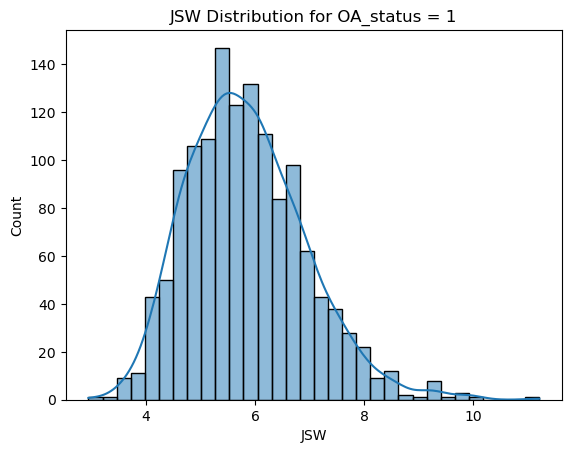

In [34]:
#visualise the distribution
sns.histplot(df_cleaned[df_cleaned["OA_status"] == 1]["JSW"], kde=True)
plt.title("JSW Distribution for OA_status = 1")
plt.show()

In [35]:
from scipy.stats import levene

In [36]:
def homogenity_test(df: pd.DataFrame, independent_var: str, dependent_var: str) -> bool:
    iv_groups = df[independent_var].unique() # Step 1: Extract unique values in the IV column (groups)
    dv_groups = [df[df[independent_var] == group][dependent_var] for group in iv_groups]  # Step 2: Collect values of the dependent variable for each group into a list
    stat, p_value = levene(*dv_groups)  # Step 3: Perform Levene's test
    if p_value > 0.05:  # Step 4: Check p-value
        print(f"Homogeneity of variance holds: p-value = {p_value:.4f}")
        return True
    else:
        print(f"Homogeneity of variance does not hold: p-value = {p_value:.4f}") #Step 5 
        return False
# Call the function to see the output
homogenity_test(df_cleaned, "OA_status", "JSW")       
# # Example usage with df_cleaned
result = homogenity_test(df_cleaned, "OA_status", "JSW")
print("Homogeneity test result:", result)

Homogeneity of variance does not hold: p-value = 0.0000
Homogeneity of variance does not hold: p-value = 0.0000
Homogeneity test result: False


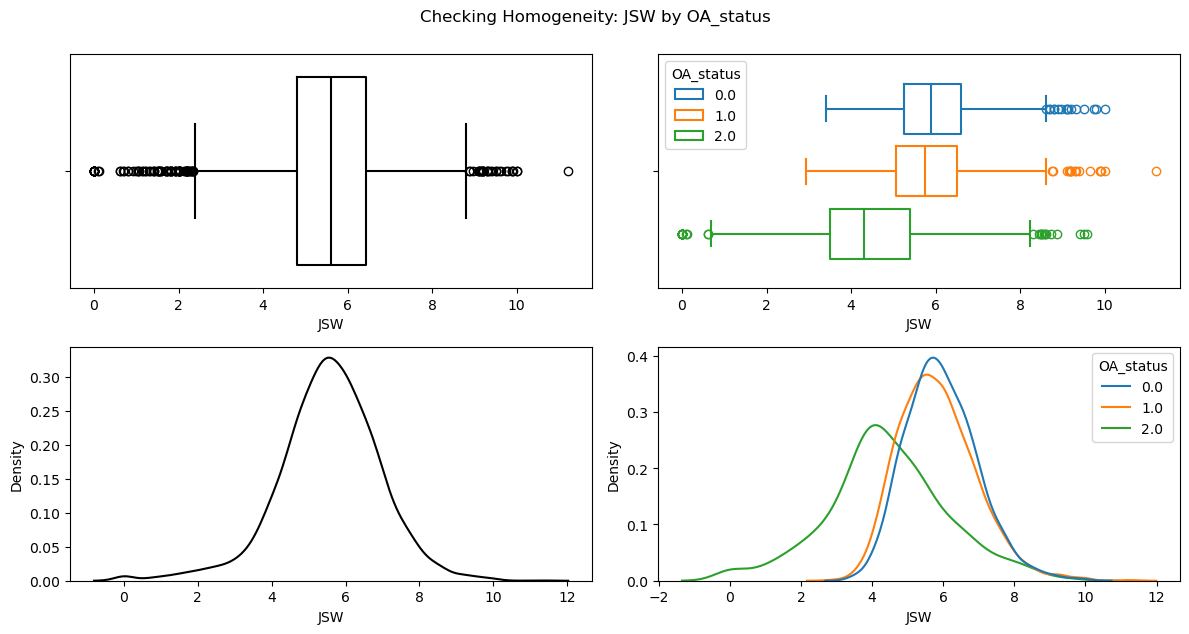

Homogeneity of variance does not hold: p-value = 0.0000
Homogeneity test result: False


In [37]:
# Visualize and test for homogeneity
iv = "OA_status"
dv = "JSW"

# Step 1: Visualize using plot_sample_groups
plot_sample_groups(df_cleaned, iv, dv)
plt.suptitle(f"Checking Homogeneity: {dv} by {iv}", y=1.05)  # Add a title
plt.show()

# Step 2: Run the homogeneity test
result = homogenity_test(df_cleaned, iv, dv)
print("Homogeneity test result:", result)

In [38]:
# iv = "OA_status"
# dv = "JSW"

# # Simple boxplot
# sns.boxplot(x=iv, y=dv, data=df_cleaned)
# plt.title(f"Homogeneity Check: {dv} by {iv}")
# plt.show()

# # Run the test
# result = homogenity_test(df_cleaned, iv, dv)
# print("Homogeneity test result:", result)

In [39]:
# def homogenity_test(df: pd.DataFrame, independent_var: str, dependent_var: str) -> bool:
#     print(f"Testing homogeneity for IV: {independent_var}, DV: {dependent_var}")
#     iv_groups = df[independent_var].unique()
#     print(f"Step 1: Unique IV groups = {iv_groups}")
#     dv_groups = [df[df[independent_var] == group][dependent_var] for group in iv_groups]
#     print(f"Step 2: Group sizes = {[len(g) for g in dv_groups]}")
#     stat, p_value = levene(*dv_groups)
#     print(f"Step 3: Levene p-value = {p_value:.4f}")
#     if p_value > 0.05:
#         print(f"Homogeneity of variance holds: p-value = {p_value:.4f}")
#         return True
#     else:
#         print(f"Homogeneity of variance does not hold: p-value = {p_value:.4f}")
#         return False

# result = homogenity_test(df_cleaned, "OA_status", "JSW")
# print("Homogeneity test result:", result)

---
### **Task 1.3: Sample data (1.5 pts)** 
The function **`sample_data(df, independent_var, dependent_var)`** repeatedly selects **100 observations** until the normality and homogeneity conditions are met.  

**Steps:**  

1. Start a **while loop** that continues until a valid sample is found.  
2. Generate a **random integer number** (seed) between 0 and 30.  
3. Randomly select **100 samples** from the dataframe using the random number as `random_state` for reproducibility.  
4. Run `normality_test()` and `homogeneity_test()`.  
5. If both tests return **`True`**, exit the loop and return the sample and random seed. Otherwise, repeat the process.  

Call function sample_data() with `OA_status` as independent and `JSW` as dependent variable


All groups pass normality test (p > 0.05)
Homogeneity of variance does not hold: p-value = 0.0289
Seed 8 failed (missing groups or test failed). Trying again.....
Group 0.0 fails normality test: p-value = 0.0055
Homogeneity of variance does not hold: p-value = 0.0001
Seed 9 failed (missing groups or test failed). Trying again.....
All groups pass normality test (p > 0.05)
Homogeneity of variance does not hold: p-value = 0.0141
Seed 3 failed (missing groups or test failed). Trying again.....
All groups pass normality test (p > 0.05)
Homogeneity of variance does not hold: p-value = 0.0020
Seed 0 failed (missing groups or test failed). Trying again.....
Group 1.0 fails normality test: p-value = 0.0176
Homogeneity of variance does not hold: p-value = 0.0015
Seed 24 failed (missing groups or test failed). Trying again.....
Group 0.0 fails normality test: p-value = 0.0135
Homogeneity of variance does not hold: p-value = 0.0460
Seed 4 failed (missing groups or test failed). Trying again.....


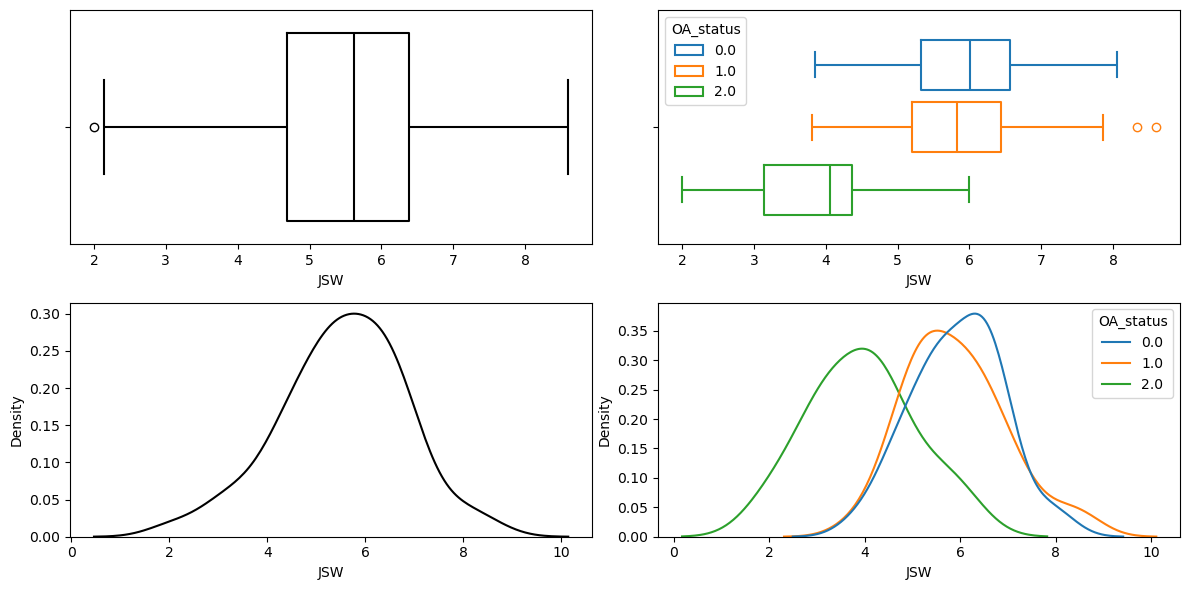

In [41]:
def sample_data(df: pd.DataFrame, independent_var: str, dependent_var: str) -> tuple:
    if len(df) < 100:
        raise ValueError("DataFrame has fewer than 100 rows, cannot sample.")
    all_groups = df[independent_var].unique()
    max_attempts = 100
    attempt = 0
    while attempt < max_attempts:
        seed = np.random.randint(0, 31)
        sample_df = df.sample(n=100, random_state=seed)
        if set(sample_df[independent_var].unique()) == set(all_groups):
            normal = normality_test(sample_df, independent_var, dependent_var) #def normality_test defined earlier
            homogeneous = homogenity_test(sample_df, independent_var, dependent_var) #def homogenity_test define earlier
            if normal and homogeneous:
                print(f"Valid sample found with seed {seed}")
                return sample_df, seed
        print(f"Seed {seed} failed (missing groups or test failed). Trying again.....")
        attempt += 1
    raise ValueError("No valid sample found after 100 attempts.")

# Visualize data after task passed df_cleaned derived above already
df, seed = sample_data(df=df_cleaned, independent_var="OA_status", dependent_var="JSW")
plot_sample_groups(df, 'OA_status', 'JSW')
plt.show()

# #Visualize data after task passed
# df, seed = sample_data(df=df_OAI, independent_var="OA_status", dependent_var="JSW")
# plot_sample_groups(df,'OA_status','JSW')

---
---
## **Task 2: ANOVA Test (8 pts)**
The aims of this task are to review the knowledge about ANOVA, different types of ANOVA and how to apply it for specific hypotheses.  

### **Task 2.1: Knowledge Recap (2 pts)** 

1. In task 1, we randomly sampled data that satisfies normality and homoscedasticity, is the sampled data now valid for an ANOVA test? Why? (0.5 pts)

**Your answer here**:


...

**Normality**:
The data (JSW values) within each OA_status group (0, 1, 2) follows a normal distribution (Shapiro-Wilk test, p > 0.05).

**Homogeneity of Variance**:
The variance of JSW values is similar across all OA_status groups (Levene's test, p > 0.05).

**Independence**:
Assumed to be satisfied based on the data collection method (independent observations).

**Validation**:
The sample was specifically selected (using seed ) to meet both normality and homogeneity of variance criteria.

**ANOVA Applicability**:
Because the assumptions of normality, homogeneity of variance, and independence are met, a one-way ANOVA can be used to compare the means of JSW across the OA_status groups.


2. Consider the following code snippet:  

```python
            import statsmodels.formula.api as smf

            model_formula = 'JSW ~ C(INJURY) + C(SEX) + C(OA_status) + \
                            C(INJURY):C(SEX) + C(INJURY):C(OA_status) + \
                            C(SEX):C(OA_status) + C(INJURY):C(SEX):C(OA_status)'

            model = smf.ols(model_formula, data=df).fit()
```
If someone apply ANOVA test following this model, what is the general null hypothesis? (0.5 pts)


**Your answer here**:


...
**Model**:

This model is called the Ordinary Least Squares (OLS) regression model, which predicts Joint Space Width (JSW).
The model includes:
Main effects of the categorical variables.
All possible interactions between these variables, up to the third order (a "full factorial" model).

**ANOVA Application**:

After fitting the OLS model, an ANOVA table is generated.
This ANOVA tests the significance of each term (main effects and interactions) in the model.
It determines how well each term explains the variation in JSW.

**Null Hypothesis (H₀)**:

For each term (main effect or interaction), the null hypothesis states that the term has no significant effect on JSW.
In other words the regression coefficients associated with that term are equal to zero.

**Alternative Hypothesis (H₁)**:

The alternative hypothesis states that at least one coefficient for that term is not zero, meaning the term does have a significant effect on JSW.



3. What type of ANOVA test can be used to test the hypotheses from Question 1? Why? (0.5 pts)

**Your answer here**:


...

**Suitable ANOVA**:

Factorial ANOVA (via OLS + ANOVA Table)

Because:
Normality: Satisfied (p > 0.05 for all groups).

Homogeneity: Satisfied (p = 0.1758 > 0.05).

Independence: Assumed from a random sampling of df_cleaned.

Multifactor Design: The model includes multiple categorical IVs (INJURY, SEX, OA_status) and their interactions, making factorial ANOVA ideal.

What It Tests: Significance of each term (main effects and interactions) in explaining JSW variance.

4. Now, observe the following modified code:
```python
            model_formula = 'JSW + BMI ~ C(INJURY) + C(SEX) + C(OA_status) + \
                            C(INJURY):C(SEX) + C(INJURY):C(OA_status) + \
                            C(SEX):C(OA_status) + C(INJURY):C(SEX):C(OA_status)'
```
Can the ANOVA test you identified in Question 2 be applied to this new model? Why or why not? (0.5 pts)

**Your answer here**:


...

**MANOVA**: To analyze both JSW and BMI as DVs with IVs and interactions, MANOVA is the correct approach, not ANOVA.

**Why**: ANOVA is univariate; MANOVA handles multivariate outcomes, matching the modified formula’s intent (assuming JSW + BMI means two DVs).

---
### **Task 2.2: One-way ANOVA and pairwise test (4 pts)**
Your task is to **implement the One-Way ANOVA test** and print out the conclusion by completing the `oneway_anova()` function. Then, implement Tukey's HSD (Honest Significant Difference) test as a post-hoc test for ANOVA. 

**1. Steps to complete the function (2 pts)**:
1. The function should take three parameters:  the dataset, independent_var, dependent_var
2. Fit an ANOVA model using `statsmodels` and perform the test (please refer to Lecture 8 for further details)
3. Extract p-value from ANOVA results
4. Print the conclusion by comparing p-value with 0.05. The format of conclusion:
     - If p-value < 0.05, "There is significant difference in {dependent_var} among levels of {independent_var}"
     - If p-value >= 0.05, "No significant difference in {dependent_var} among levels of {independent_var}"
     
**2. Apply the function (1 pt)**:
Call `oneway_anova()` to perform on sampled data from task 1 and determine whether there is a **significant difference** in:
- **JSW** between different stages of OA (using **OA_status**).
- **BMI** between different stages of OA.

**3. Post-hoc analysis (1 pt)**:
- Use `pairwise_tukeyhsd()` from `statsmodels.stats.multicomp` to perform Tukey’s HSD test.
- Print the results to interpret the pairwise comparisons. 

In [51]:
def oneway_anova(df:pd.DataFrame, independent_var:str, dependent_var:str) -> str:
    #TODO: Write your code here
    pass

# TODO: Call oneway_anova to test the significant difference in JSM, and BMI among levels of OA_status 

from statsmodels.stats.multicomp import pairwise_tukeyhsd
#TODO: Write your code here to perform post-hoc analysis

   """
    Perform a one-way ANOVA test and print the conclusion.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame (e.g., sampled_df).
        independent_var (str): Categorical independent variable (e.g., 'OA_status').
        dependent_var (str): Continuous dependent variable (e.g., 'JSW').
    
    Returns:
        None: Prints the ANOVA conclusion.
    """

In [99]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

sampled_df, seed = sample_data(df_cleaned, "OA_status", "JSW")

def oneway_anova(df: pd.DataFrame, independent_var: str, dependent_var: str) -> str:
 
    # Step 1: Fit the ANOVA model using statsmodels
   
    formula = f"{dependent_var} ~ C({independent_var})"  # Formula: dependent_var ~ C(independent_var)
    model = smf.ols(formula, data=df).fit()
    
    # Step 2: Perform the ANOVA test
    anova_results = anova_lm(model, typ=1)  # Type 1 for one-way ANOVA
    
    # Step 3: Extract p-value from ANOVA results
    p_value = anova_results['PR(>F)'][0]  # p-value for the independent variable
    
    # Step 4: Print conclusion based on p-value
    if p_value < 0.05:
        print(f"There is significant difference in {dependent_var} among levels of {independent_var}")
    else:
        print(f"No significant difference in {dependent_var} among levels of {independent_var}")
    print(f"p-value: {p_value:.4f}")  # Optional: Show p-value for reference

# Example usage with sampled_df (from seed 18)
# Assuming sampled_df is defined from your earlier sample_data() call
oneway_anova(sampled_df, "OA_status", "JSW")

All groups pass normality test (p > 0.05)
Homogeneity of variance does not hold: p-value = 0.0011
Seed 16 failed (missing groups or test failed). Trying again.....
Group 0.0 fails normality test: p-value = 0.0055
Homogeneity of variance does not hold: p-value = 0.0001
Seed 9 failed (missing groups or test failed). Trying again.....
All groups pass normality test (p > 0.05)
Homogeneity of variance holds: p-value = 0.2058
Valid sample found with seed 13
There is significant difference in JSW among levels of OA_status
p-value: 0.0029


C:\Users\Hi\AppData\Local\Temp\ipykernel_32524\980425323.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_results['PR(>F)'][0]  # p-value for the independent variable


In [101]:
# sampled_df, seed = sample_data(df_cleaned, "OA_status", "JSW")

def oneway_anova(df: pd.DataFrame, independent_var: str, dependent_var: str) -> str:
    # Step 1: Fit the ANOVA model using statsmodels
    formula = f"{dependent_var} ~ C({independent_var})"
    model = smf.ols(formula, data=df).fit()
    
    # Step 2: Perform the ANOVA test
    anova_results = anova_lm(model, typ=1)
    
    # Step 3: Extract p-value from ANOVA results
    p_value = anova_results['PR(>F)'][0]
    
    # Step 4: Print conclusion based on p-value
    if p_value < 0.05:
        print(f"There is significant difference in {dependent_var} among levels of {independent_var}")
    else:
        print(f"No significant difference in {dependent_var} among levels of {independent_var}")
    print(f"p-value: {p_value:.4f}")

# Perform one-way ANOVA for JSW
print("ANOVA for JSW:")
oneway_anova(sampled_df, "OA_status", "JSW")

# Perform one-way ANOVA for BMI
print("\nANOVA for BMI:")
oneway_anova(sampled_df, "OA_status", "BMI")

ANOVA for JSW:
There is significant difference in JSW among levels of OA_status
p-value: 0.0029

ANOVA for BMI:
No significant difference in BMI among levels of OA_status
p-value: 0.1394


C:\Users\Hi\AppData\Local\Temp\ipykernel_32524\2511874127.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_results['PR(>F)'][0]
C:\Users\Hi\AppData\Local\Temp\ipykernel_32524\2511874127.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_results['PR(>F)'][0]


In [103]:
# import statsmodels.formula.api as smf
# from statsmodels.stats.anova import anova_lm
# from statsmodels.stats.multicomp import pairwise_tukeyhsd

def oneway_anova(df: pd.DataFrame, independent_var: str, dependent_var: str) -> str:
    formula = f"{dependent_var} ~ C({independent_var})"
    model = smf.ols(formula, data=df).fit()
    anova_results = anova_lm(model, typ=1)
    p_value = anova_results['PR(>F)'].iloc[0]  # Fixed with .iloc[0]
    if p_value < 0.05:
        conclusion = f"There is significant difference in {dependent_var} among levels of {independent_var}"
        print(conclusion)
        # Perform Tukey's HSD if significant
        tukey_result = pairwise_tukeyhsd(endog=df[dependent_var], 
                                        groups=df[independent_var], 
                                        alpha=0.05)
        print(f"\nTukey's HSD Results for {dependent_var}:")
        print(tukey_result)
    else:
        conclusion = f"No significant difference in {dependent_var} among levels of {independent_var}"
        print(conclusion)
    print(f"p-value: {p_value:.4f}")
    # Return conclusion (optional, aligning with -> str)
    return conclusion

# Test JSW
print("ANOVA for JSW:")
oneway_anova(sampled_df, "OA_status", "JSW")

# Test BMI
print("\nANOVA for BMI:")
oneway_anova(sampled_df, "OA_status", "BMI")

ANOVA for JSW:
There is significant difference in JSW among levels of OA_status

Tukey's HSD Results for JSW:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   0.0    1.0   -0.108 0.9263 -0.7973  0.5813  False
   0.0    2.0  -1.0597 0.0055 -1.8517 -0.2678   True
   1.0    2.0  -0.9517  0.007 -1.6812 -0.2222   True
----------------------------------------------------
p-value: 0.0029

ANOVA for BMI:
No significant difference in BMI among levels of OA_status
p-value: 0.1394


'No significant difference in BMI among levels of OA_status'

---
### **Task 2.3: Two-way ANOVA (2 pts)**
Your task is to **implement the Two-Way ANOVA test** and print out the conclusion by completing the `twoway_anova()` function.

**1. Steps to complete the function (1.5 pts)**:
1. The function should take three parameters:  the dataset, independent_var - a list containing two variables, dependent_var
2. Fit a Two-way ANOVA model using `statsmodels` and perform the test (please refer to Lecture 8 for further details)
3. Extract p-value for both independent variables
4. Evaluate significance by comparing p-value with 0.05 and print conclusion. The format of conclusion:
     - If p-value < 0.05, "There is significant difference in {dependent_var} among levels of {independent_var1} and {independent_var2}"
     - If p-value >= 0.05, "No significant difference in {dependent_var} among levels of {independent_var} and {independent_var2}"
     
     
**2. Apply the function (0.5 pt)**:
Call `twoway_anova()` to perform on sampled data from task 1 and determine whether there is a **significant difference** in:
- **JSW** between different stages of OA status (column **OA_status**) and injury (column **INJURY**).


In [ ]:
def twoway_anova(df:pd.DataFrame, independent_var1:str, independent_var2:str, dependent_var:str) -> str:
    #TODO: Write your code here
    pass

#TODO: call function

 """
      """
    Perform a Two-Way ANOVA test and print the conclusion.
    
    Parameters:
        dataset (pd.DataFrame): Input DataFrame (e.g., sampled_df).
        independent_var (list): List of two categorical independent variables (e.g., ['OA_status', 'INJURY']).
        dependent_var (str): Continuous dependent variable (e.g., 'JSW').
    
    Returns:
        None: Prints the ANOVA conclusion.
    """
    """

In [111]:
def twoway_anova(dataset: pd.DataFrame, independent_var: list, dependent_var: str) -> None:
  
    # Check that independent_var has exactly two variables
    if len(independent_var) != 2:
        raise ValueError("independent_var must contain exactly two variables")
    iv1, iv2 = independent_var[0], independent_var[1]
    
    # Fit the Two-Way ANOVA model with main effects and interaction
    formula = f"{dependent_var} ~ C({iv1}) + C({iv2}) + C({iv1}):C({iv2})"
    model = smf.ols(formula, data=dataset).fit()
    
    # Perform the ANOVA test
    anova_results = anova_lm(model, typ=2)
    
    # Extract p-values for both independent variables and their interaction
    p_value_iv1 = anova_results['PR(>F)'].loc[f"C({iv1})"]
    p_value_iv2 = anova_results['PR(>F)'].loc[f"C({iv2})"]
    p_value_interaction = anova_results['PR(>F)'].loc[f"C({iv1}):C({iv2})"]
    
    # Print p-values for reference
    print(f"p-value for {iv1}: {p_value_iv1:.4f}")
    print(f"p-value for {iv2}: {p_value_iv2:.4f}")
    print(f"p-value for {iv1}:{iv2} interaction: {p_value_interaction:.4f}")
    
    # Evaluate significance and print conclusion
    if p_value_iv1 < 0.05 or p_value_iv2 < 0.05 or p_value_interaction < 0.05:
        print(f"There is significant difference in {dependent_var} among levels of {iv1} and {iv2}")
    else:
        print(f"No significant difference in {dependent_var} among levels of {iv1} and {iv2}")

# Define independent variables and apply the function
independent_vars = ["OA_status", "INJURY"]
print("Two-Way ANOVA for JSW with OA_status and INJURY:")
twoway_anova(sampled_df, independent_vars, "JSW")

Two-Way ANOVA for JSW with OA_status and INJURY:
p-value for OA_status: 0.0042
p-value for INJURY: 0.2133
p-value for OA_status:INJURY interaction: 0.4091
There is significant difference in JSW among levels of OA_status and INJURY


Two-Way ANOVA for JSW with OA_status and INJURY:
p-value for OA_status: 0.0042
p-value for INJURY: 0.2133
p-value for OA_status:INJURY interaction: 0.4091
There is significant difference in JSW among levels of OA_status and INJURY


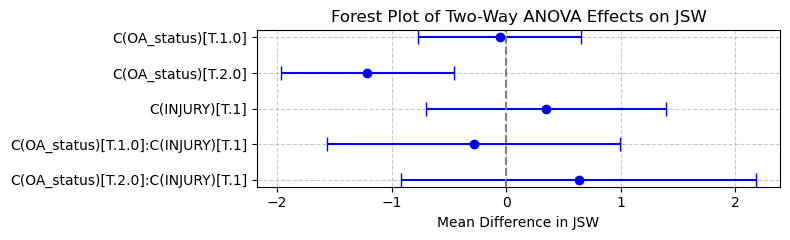

In [113]:
def twoway_anova(dataset: pd.DataFrame, independent_var: list, dependent_var: str) -> None:

    # Check that independent_var has exactly two variables
    if len(independent_var) != 2:
        raise ValueError("independent_var must contain exactly two variables")
    iv1, iv2 = independent_var[0], independent_var[1]
    
    # Fit the Two-Way ANOVA model with main effects and interaction
    formula = f"{dependent_var} ~ C({iv1}) + C({iv2}) + C({iv1}):C({iv2})"
    model = smf.ols(formula, data=dataset).fit()
    
    # Perform the ANOVA test
    anova_results = anova_lm(model, typ=2)
    
    # Extract p-values
    p_value_iv1 = anova_results['PR(>F)'].loc[f"C({iv1})"]
    p_value_iv2 = anova_results['PR(>F)'].loc[f"C({iv2})"]
    p_value_interaction = anova_results['PR(>F)'].loc[f"C({iv1}):C({iv2})"]
    
    # Print p-values
    print(f"p-value for {iv1}: {p_value_iv1:.4f}")
    print(f"p-value for {iv2}: {p_value_iv2:.4f}")
    print(f"p-value for {iv1}:{iv2} interaction: {p_value_interaction:.4f}")
    
    # Print conclusion
    if p_value_iv1 < 0.05 or p_value_iv2 < 0.05 or p_value_interaction < 0.05:
        print(f"There is significant difference in {dependent_var} among levels of {iv1} and {iv2}")
    else:
        print(f"No significant difference in {dependent_var} among levels of {iv1} and {iv2}")
    
    # Extract effect sizes and confidence intervals from the model
    params = model.params  # Coefficients (mean differences from reference)
    conf_int = model.conf_int(alpha=0.05)  # 95% confidence intervals
    
    # Filter relevant terms (exclude intercept)
    terms = [name for name in params.index if 'Intercept' not in name]
    effect_sizes = params[terms]
    ci_lower = conf_int.loc[terms, 0]
    ci_upper = conf_int.loc[terms, 1]
    
    # Create forest plot
    fig, ax = plt.subplots(figsize=(8, len(terms) * 0.5))
    y_pos = np.arange(len(terms))
    
    # Plot effect sizes with error bars (CI)
    ax.errorbar(effect_sizes, y_pos, xerr=(ci_upper - ci_lower) / 2, fmt='o', color='blue', capsize=5)
    ax.axvline(x=0, color='gray', linestyle='--')  # Line at zero (no effect)
    
    # Customize plot
    ax.set_yticks(y_pos)
    ax.set_yticklabels(terms)
    ax.set_xlabel('Mean Difference in JSW')
    ax.set_title(f'Forest Plot of Two-Way ANOVA Effects on {dependent_var}')
    ax.invert_yaxis()  # Top-down order
    
    # Add grid for readability
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Show plot
    plt.tight_layout()
    plt.show()

# Define independent variables and apply the function
independent_vars = ["OA_status", "INJURY"]
print("Two-Way ANOVA for JSW with OA_status and INJURY:")
twoway_anova(sampled_df, independent_vars, "JSW")